Libraries imported successfully!
CleaningRobotEnvironment class defined!

Cleaning Robot Grid:
S = Start, C = Cleaned, O = Obstacle, . = Uncleaned
 S  .  .  .  O 
 .  O  .  .  . 
 .  .  .  O  . 
 O  .  .  .  . 

Environment details:
Grid size: 4x5
Start position: (0, 0), direction: 1
Cleanable cells: 16
Actions: ['forward', 'turn_left', 'turn_right']

Testing environment interaction:
Initial state: ((0, 0), 1)
Step 1: Action 'forward' -> State ((0, 1), 1), Reward: 9, Done: False
Step 2: Action 'forward' -> State ((0, 2), 1), Reward: 9, Done: False
Step 3: Action 'turn_right' -> State ((0, 2), 2), Reward: -1, Done: False
Step 4: Action 'forward' -> State ((1, 2), 2), Reward: 9, Done: False
Agents defined: SARSA, Q-learning, Dyna-Q, TD(0)!

SARSA Agent created with parameters:
Number of states: 80
Number of actions: 3
Learning rate (alpha): 0.1
Discount factor (gamma): 0.9
Exploration rate (epsilon): 0.1
Q-table shape: (80, 3)

Q-learning Agent created with parameters:
Number of states: 

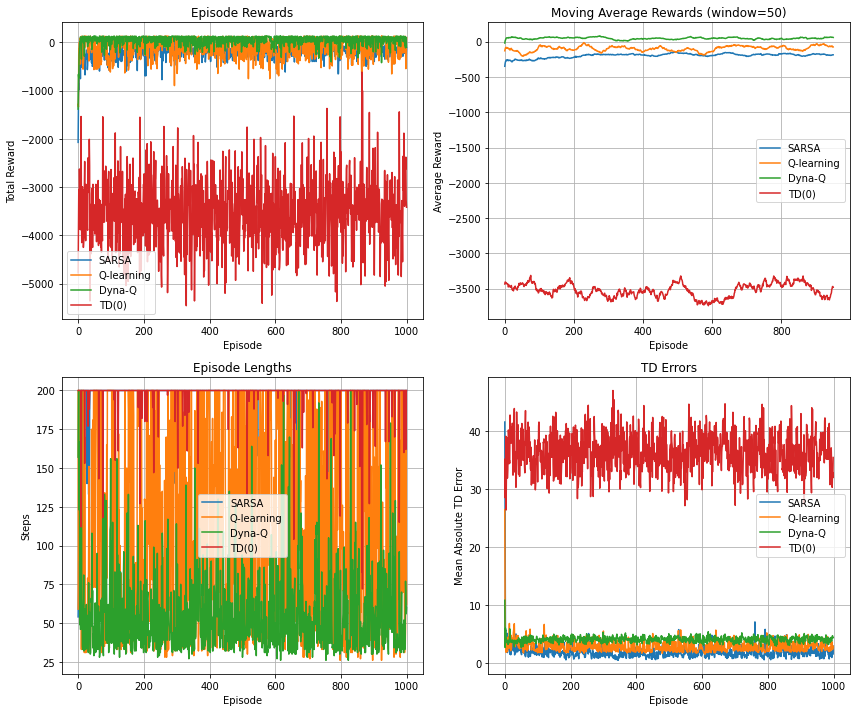


Testing SARSA policy...


TypeError: SarsaAgent.__init__() got an unexpected keyword argument 'n_planning'

In [1]:
# Cell 1: Import libraries and setup
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict

print("Libraries imported successfully!")

# %%
# Cell 2: Define Cleaning Robot Environment
class CleaningRobotEnvironment:
    """
    Cleaning Robot Environment
    Grid: NxM where 0 indicates cleanable cell, non-zero indicates obstructed
    Start: Specified (row, col) position and direction (0: up, 1: right, 2: down, 3: left)
    Goal: Clean all cleanable cells
    Actions: forward, turn_left, turn_right
    """
    
    def __init__(self, matrix, start_pos, start_direction):
        self.matrix = np.array(matrix)
        self.height, self.width = self.matrix.shape
        self.num_actions = 3  # forward, turn_left, turn_right
        self.actions = ['forward', 'turn_left', 'turn_right']
        self.start_pos = start_pos
        self.start_direction = start_direction % 4  # 0: up, 1: right, 2: down, 3: left
        self.current_pos = start_pos
        self.current_direction = start_direction
        self.cleaned = set()  # Track cleaned cells
        self.cleanable = {(i, j) for i in range(self.height) for j in range(self.width) if self.matrix[i, j] == 0}
        
    def reset(self):
        """Reset environment to start position and direction"""
        self.current_pos = self.start_pos
        self.current_direction = self.start_direction
        self.cleaned = set()
        return (self.current_pos, self.current_direction)
    
    def step(self, action):
        """Take action and return (next_state, reward, done)"""
        row, col = self.current_pos
        direction = self.current_direction
        
        # Apply action
        if action == 0:  # forward
            if direction == 0:  # up
                new_row, new_col = row - 1, col
            elif direction == 1:  # right
                new_row, new_col = row, col + 1
            elif direction == 2:  # down
                new_row, new_col = row + 1, col
            elif direction == 3:  # left
                new_row, new_col = row, col - 1
            # Check bounds and obstacles
            if (0 <= new_row < self.height and 0 <= new_col < self.width and self.matrix[new_row, new_col] == 0):
                self.current_pos = (new_row, new_col)
                reward = -1  # Cost of movement
                if (new_row, new_col) not in self.cleaned:
                    self.cleaned.add((new_row, new_col))
                    reward += 10  # Reward for cleaning a new cell
            else:
                reward = -100  # Penalty for hitting obstacle or wall
        elif action == 1:  # turn_left
            self.current_direction = (direction - 1) % 4
            reward = -1  # Cost of turning
        elif action == 2:  # turn_right
            self.current_direction = (direction + 1) % 4
            reward = -1  # Cost of turning
        else:
            raise ValueError(f"Invalid action: {action}")
        
        done = self.cleaned == self.cleanable
        next_state = (self.current_pos, self.current_direction)
        return next_state, reward, done
    
    def get_state_id(self, state):
        """Convert (position, direction) to state ID"""
        (row, col), direction = state
        return (row * self.width + col) * 4 + direction
    
    def get_position(self, state_id):
        """Convert state ID to (position, direction)"""
        direction = state_id % 4
        pos_id = state_id // 4
        row = pos_id // self.width
        col = pos_id % self.width
        return ((row, col), direction)
    
    def print_grid(self, policy=None, values=None):
        """Print the grid world"""
        print("\nCleaning Robot Grid:")
        print("S = Start, C = Cleaned, O = Obstacle, . = Uncleaned")
        for row in range(self.height):
            row_str = ""
            for col in range(self.width):
                pos = (row, col)
                if pos == self.start_pos:
                    row_str += " S "
                elif pos in self.cleaned:
                    row_str += " C "
                elif self.matrix[row, col] != 0:
                    row_str += " O "
                else:
                    row_str += " . "
            print(row_str)
        
        if policy is not None:
            print("\nPolicy (F: forward, L: left, R: right):")
            symbols = ['F', 'L', 'R']
            for row in range(self.height):
                for direction in range(4):
                    row_str = f"Direction {direction}: "
                    for col in range(self.width):
                        pos = (row, col)
                        if self.matrix[row, col] != 0:
                            row_str += " O "
                        else:
                            state_id = self.get_state_id((pos, direction))
                            action = np.argmax(policy[state_id])
                            row_str += f" {symbols[action]} "
                    print(row_str)
        
        if values is not None:
            print("\nState Values:")
            for row in range(self.height):
                for direction in range(4):
                    row_str = f"Direction {direction}: "
                    for col in range(self.width):
                        pos = (row, col)
                        state_id = self.get_state_id((pos, direction))
                        if self.matrix[row, col] != 0:
                            row_str += "   O  "
                        else:
                            row_str += f"{values[state_id]:5.1f} "
                    print(row_str)

print("CleaningRobotEnvironment class defined!")

# %%
# Cell 3: Test the environment and interaction
matrix = [
    [0, 0, 0, 0, 1],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [1, 0, 0, 0, 0]
]
env = CleaningRobotEnvironment(matrix, start_pos=(0, 0), start_direction=1)
env.print_grid()

print(f"\nEnvironment details:")
print(f"Grid size: {env.height}x{env.width}")
print(f"Start position: {env.start_pos}, direction: {env.start_direction}")
print(f"Cleanable cells: {len(env.cleanable)}")
print(f"Actions: {env.actions}")

print("\nTesting environment interaction:")
state = env.reset()
print(f"Initial state: {state}")

test_actions = [0, 0, 2, 0]  # forward, forward, turn_right, forward
for i, action in enumerate(test_actions):
    next_state, reward, done = env.step(action)
    print(f"Step {i+1}: Action '{env.actions[action]}' -> State {next_state}, Reward: {reward}, Done: {done}")
    if done:
        break

# %%
# Cell 4: Define Agents
class SarsaAgent:
    """SARSA Agent"""
    def __init__(self, num_states, num_actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.num_states = num_states
        self.num_actions = num_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.Q = np.zeros((num_states, num_actions))
    
    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.num_actions - 1)
        return np.argmax(self.Q[state])
    
    def sarsa_update(self, state, action, reward, next_state, next_action):
        current_q = self.Q[state, action]
        next_q = self.Q[next_state, next_action]
        td_target = reward + self.gamma * next_q
        td_error = td_target - current_q
        self.Q[state, action] += self.alpha * td_error
        return td_error
    
    def sarsa_update_terminal(self, state, action, reward):
        current_q = self.Q[state, action]
        td_target = reward
        td_error = td_target - current_q
        self.Q[state, action] += self.alpha * td_error
        return td_error
    
    def get_policy(self):
        return self.Q.copy()
    
    def get_value_function(self):
        return np.max(self.Q, axis=1)
    
    def decay_epsilon(self, decay_rate=0.995, min_epsilon=0.01):
        self.epsilon = max(min_epsilon, self.epsilon * decay_rate)

class QLearningAgent:
    """Q-learning Agent"""
    def __init__(self, num_states, num_actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.num_states = num_states
        self.num_actions = num_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.Q = np.zeros((num_states, num_actions))
    
    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.num_actions - 1)
        return np.argmax(self.Q[state])
    
    def q_learning_update(self, state, action, reward, next_state):
        current_q = self.Q[state, action]
        max_next_q = np.max(self.Q[next_state])
        td_target = reward + self.gamma * max_next_q
        td_error = td_target - current_q
        self.Q[state, action] += self.alpha * td_error
        return td_error
    
    def q_learning_update_terminal(self, state, action, reward):
        current_q = self.Q[state, action]
        td_target = reward
        td_error = td_target - current_q
        self.Q[state, action] += self.alpha * td_error
        return td_error
    
    def get_policy(self):
        return self.Q.copy()
    
    def get_value_function(self):
        return np.max(self.Q, axis=1)
    
    def decay_epsilon(self, decay_rate=0.995, min_epsilon=0.01):
        self.epsilon = max(min_epsilon, self.epsilon * decay_rate)

class DynaQAgent:
    """Dyna-Q Agent"""
    def __init__(self, num_states, num_actions, alpha=0.1, gamma=0.9, epsilon=0.1, n_planning=5):
        self.num_states = num_states
        self.num_actions = num_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.n_planning = n_planning
        self.Q = np.zeros((num_states, num_actions))
        self.model = defaultdict(lambda: defaultdict(list))
        self.visited = set()
    
    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.num_actions - 1)
        return np.argmax(self.Q[state])
    
    def update_model(self, state, action, reward, next_state, done):
        self.visited.add((state, action))
        self.model[state][action].append((next_state, reward, done))
    
    def q_learning_update(self, state, action, reward, next_state):
        current_q = self.Q[state, action]
        max_next_q = np.max(self.Q[next_state]) if not next_state == env.get_state_id((env.current_pos, env.current_direction)) else 0
        td_target = reward + self.gamma * max_next_q
        td_error = td_target - current_q
        self.Q[state, action] += self.alpha * td_error
        return td_error
    
    def q_learning_update_terminal(self, state, action, reward):
        current_q = self.Q[state, action]
        td_target = reward
        td_error = td_target - current_q
        self.Q[state, action] += self.alpha * td_error
        return td_error
    
    def planning(self):
        for _ in range(self.n_planning):
            if not self.visited:
                continue
            state, action = random.choice(list(self.visited))
            if self.model[state][action]:
                next_state, reward, done = random.choice(self.model[state][action])
                if done:
                    self.q_learning_update_terminal(state, action, reward)
                else:
                    self.q_learning_update(state, action, reward, next_state)
    
    def get_policy(self):
        return self.Q.copy()
    
    def get_value_function(self):
        return np.max(self.Q, axis=1)
    
    def decay_epsilon(self, decay_rate=0.995, min_epsilon=0.01):
        self.epsilon = max(min_epsilon, self.epsilon * decay_rate)

class TD0Agent:
    """TD(0) Agent for value estimation"""
    def __init__(self, num_states, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.num_states = num_states
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.V = np.zeros(num_states)  # State values
        self.policy = np.ones((num_states, env.num_actions)) / env.num_actions  # Random policy
    
    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, env.num_actions - 1)
        return np.random.choice(range(env.num_actions), p=self.policy[state])
    
    def td0_update(self, state, reward, next_state):
        current_v = self.V[state]
        next_v = self.V[next_state]
        td_target = reward + self.gamma * next_v
        td_error = td_target - current_v
        self.V[state] += self.alpha * td_error
        return td_error
    
    def td0_update_terminal(self, state, reward):
        current_v = self.V[state]
        td_target = reward
        td_error = td_target - current_v
        self.V[state] += self.alpha * td_error
        return td_error
    
    def get_value_function(self):
        return self.V.copy()

print("Agents defined: SARSA, Q-learning, Dyna-Q, TD(0)!")

# %%
# Cell 5: Create and initialize agents
num_states = env.height * env.width * 4  # Position x Direction
agents = {
    'SARSA': SarsaAgent(num_states, env.num_actions, alpha=0.1, gamma=0.9, epsilon=0.1),
    'Q-learning': QLearningAgent(num_states, env.num_actions, alpha=0.1, gamma=0.9, epsilon=0.1),
    'Dyna-Q': DynaQAgent(num_states, env.num_actions, alpha=0.1, gamma=0.9, epsilon=0.1, n_planning=5),
    'TD(0)': TD0Agent(num_states, alpha=0.1, gamma=0.9, epsilon=0.1)
}

for name, agent in agents.items():
    print(f"\n{name} Agent created with parameters:")
    print(f"Number of states: {agent.num_states if name != 'TD(0)' else num_states}")
    print(f"Number of actions: {agent.num_actions if name != 'TD(0)' else env.num_actions}")
    print(f"Learning rate (alpha): {agent.alpha}")
    print(f"Discount factor (gamma): {agent.gamma}")
    print(f"Exploration rate (epsilon): {agent.epsilon}")
    if name == 'Dyna-Q':
        print(f"Planning steps (n): {agent.n_planning}")
    print(f"{'Q-table' if name != 'TD(0)' else 'V-table'} shape: {agent.Q.shape if name != 'TD(0)' else agent.V.shape}")

# %%
# Cell 6: Train agents with step-by-step demonstration and full training
def train_sarsa(env, agent, episodes=1000, verbose=True):
    episode_rewards = []
    episode_lengths = []
    td_errors_history = []
    
    if verbose:
        print(f"Starting SARSA training for {episodes} episodes...")
    
    for episode in range(episodes):
        state = env.reset()
        state_id = env.get_state_id(state)
        action = agent.select_action(state_id)
        episode_reward = 0
        episode_length = 0
        episode_td_errors = []
        max_steps = 200
        
        while episode_length < max_steps:
            next_state, reward, done = env.step(action)
            next_state_id = env.get_state_id(next_state)
            
            if done:
                td_error = agent.sarsa_update_terminal(state_id, action, reward)
            else:
                next_action = agent.select_action(next_state_id)
                td_error = agent.sarsa_update(state_id, action, reward, next_state_id, next_action)
                action = next_action
            
            episode_td_errors.append(abs(td_error))
            episode_reward += reward
            state_id = next_state_id
            episode_length += 1
            
            if done:
                break
        
        episode_rewards.append(episode_reward)
        episode_lengths.append(episode_length)
        td_errors_history.append(np.mean(episode_td_errors))
        if episode % 100 == 0:
            agent.decay_epsilon()
        if verbose and episode % 200 == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            avg_length = np.mean(episode_lengths[-100:])
            print(f"Episode {episode}: Avg Reward = {avg_reward:.1f}, Avg Length = {avg_length:.1f}, Epsilon = {agent.epsilon:.3f}")
    
    return episode_rewards, episode_lengths, td_errors_history

def train_q_learning(env, agent, episodes=1000, verbose=True):
    episode_rewards = []
    episode_lengths = []
    td_errors_history = []
    
    if verbose:
        print(f"Starting Q-learning training for {episodes} episodes...")
    
    for episode in range(episodes):
        state = env.reset()
        state_id = env.get_state_id(state)
        episode_reward = 0
        episode_length = 0
        episode_td_errors = []
        max_steps = 200
        
        while episode_length < max_steps:
            action = agent.select_action(state_id)
            next_state, reward, done = env.step(action)
            next_state_id = env.get_state_id(next_state)
            
            if done:
                td_error = agent.q_learning_update_terminal(state_id, action, reward)
            else:
                td_error = agent.q_learning_update(state_id, action, reward, next_state_id)
            
            episode_td_errors.append(abs(td_error))
            episode_reward += reward
            state_id = next_state_id
            episode_length += 1
            
            if done:
                break
        
        episode_rewards.append(episode_reward)
        episode_lengths.append(episode_length)
        td_errors_history.append(np.mean(episode_td_errors))
        if episode % 100 == 0:
            agent.decay_epsilon()
        if verbose and episode % 200 == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            avg_length = np.mean(episode_lengths[-100:])
            print(f"Episode {episode}: Avg Reward = {avg_reward:.1f}, Avg Length = {avg_length:.1f}, Epsilon = {agent.epsilon:.3f}")
    
    return episode_rewards, episode_lengths, td_errors_history

def train_dyna_q(env, agent, episodes=1000, verbose=True):
    episode_rewards = []
    episode_lengths = []
    td_errors_history = []
    
    if verbose:
        print(f"Starting Dyna-Q training for {episodes} episodes...")
    
    for episode in range(episodes):
        state = env.reset()
        state_id = env.get_state_id(state)
        episode_reward = 0
        episode_length = 0
        episode_td_errors = []
        max_steps = 200
        
        while episode_length < max_steps:
            action = agent.select_action(state_id)
            next_state, reward, done = env.step(action)
            next_state_id = env.get_state_id(next_state)
            
            agent.update_model(state_id, action, reward, next_state_id, done)
            if done:
                td_error = agent.q_learning_update_terminal(state_id, action, reward)
            else:
                td_error = agent.q_learning_update(state_id, action, reward, next_state_id)
            agent.planning()
            
            episode_td_errors.append(abs(td_error))
            episode_reward += reward
            state_id = next_state_id
            episode_length += 1
            
            if done:
                break
        
        episode_rewards.append(episode_reward)
        episode_lengths.append(episode_length)
        td_errors_history.append(np.mean(episode_td_errors))
        if episode % 100 == 0:
            agent.decay_epsilon()
        if verbose and episode % 200 == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            avg_length = np.mean(episode_lengths[-100:])
            print(f"Episode {episode}: Avg Reward = {avg_reward:.1f}, Avg Length = {avg_length:.1f}, Epsilon = {agent.epsilon:.3f}")
    
    return episode_rewards, episode_lengths, td_errors_history

def train_td0(env, agent, episodes=1000, verbose=True):
    episode_rewards = []
    episode_lengths = []
    td_errors_history = []
    
    if verbose:
        print(f"Starting TD(0) training for {episodes} episodes...")
    
    for episode in range(episodes):
        state = env.reset()
        state_id = env.get_state_id(state)
        episode_reward = 0
        episode_length = 0
        episode_td_errors = []
        max_steps = 200
        
        while episode_length < max_steps:
            action = agent.select_action(state_id)
            next_state, reward, done = env.step(action)
            next_state_id = env.get_state_id(next_state)
            
            if done:
                td_error = agent.td0_update_terminal(state_id, reward)
            else:
                td_error = agent.td0_update(state_id, reward, next_state_id)
            
            episode_td_errors.append(abs(td_error))
            episode_reward += reward
            state_id = next_state_id
            episode_length += 1
            
            if done:
                break
        
        episode_rewards.append(episode_reward)
        episode_lengths.append(episode_length)
        td_errors_history.append(np.mean(episode_td_errors))
        if verbose and episode % 200 == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            avg_length = np.mean(episode_lengths[-100:])
            print(f"Episode {episode}: Avg Reward = {avg_reward:.1f}, Avg Length = {avg_length:.1f}")
    
    return episode_rewards, episode_lengths, td_errors_history

# Step-by-step demonstration for Dyna-Q
print("Running a single Dyna-Q episode step-by-step:")
agent = agents['Dyna-Q']
state = env.reset()
state_id = env.get_state_id(state)
action = agent.select_action(state_id)
print(f"Starting state: {state}, state_id: {state_id}")
print(f"Initial action: {env.actions[action]}")

episode_reward = 0
step_count = 0
max_steps = 15

while step_count < max_steps:
    print(f"\nStep {step_count + 1}:")
    print(f"Current state: {state_id} {env.get_position(state_id)}")
    print(f"Current action: {env.actions[action]}")
    print(f"Q-values for current state: {agent.Q[state_id]}")
    
    next_state, reward, done = env.step(action)
    next_state_id = env.get_state_id(next_state)
    print(f"Result: next_state={next_state}, reward={reward}, done={done}")
    
    agent.update_model(state_id, action, reward, next_state_id, done)
    if done:
        td_error = agent.q_learning_update_terminal(state_id, action, reward)
        print(f"Q-learning update (terminal): Q({state_id},{action}) updated, TD error: {td_error:.3f}")
    else:
        td_error = agent.q_learning_update(state_id, action, reward, next_state_id)
        print(f"Q-learning update: Q({state_id},{action}) updated, TD error: {td_error:.3f}")
        action = agent.select_action(next_state_id)
        print(f"Next action: {env.actions[action]}")
    agent.planning()
    print(f"Performed {agent.n_planning} planning steps")
    
    episode_reward += reward
    state_id = next_state_id
    step_count += 1
    
    if done:
        print(f"\nEpisode finished! Total reward: {episode_reward}, Steps: {step_count}")
        break

print("\n" + "="*60)
print("STARTING FULL TRAINING")
print("="*60)

# Train all agents
results = {}
for name, agent in agents.items():
    print(f"\nTraining {name}...")
    env.reset()
    if name == 'SARSA':
        results[name] = train_sarsa(env, agent, episodes=1000, verbose=True)
    elif name == 'Q-learning':
        results[name] = train_q_learning(env, agent, episodes=1000, verbose=True)
    elif name == 'Dyna-Q':
        results[name] = train_dyna_q(env, agent, episodes=1000, verbose=True)
    elif name == 'TD(0)':
        results[name] = train_td0(env, agent, episodes=1000, verbose=True)
    print(f"{name} training completed!")
    print(f"Final average reward (last 100 episodes): {np.mean(results[name][0][-100:]):.1f}")
    print(f"Final average episode length (last 100 episodes): {np.mean(results[name][1][-100:]):.1f}")

# %%
# Cell 7: Display results and learning curves
for name, agent in agents.items():
    print(f"\n{name} Results:")
    if name != 'TD(0)':
        policy = agent.get_policy()
        values = agent.get_value_function()
        env.print_grid(policy=policy, values=values)
    else:
        values = agent.get_value_function()
        env.print_grid(values=values)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

for name, (rewards, lengths, td_errors) in results.items():
    ax1.plot(rewards, label=name)
    window = 50
    if len(rewards) >= window:
        moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax2.plot(moving_avg, label=name)
    ax3.plot(lengths, label=name)
    ax4.plot(td_errors, label=name)

ax1.set_title('Episode Rewards')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.legend()
ax1.grid(True)

ax2.set_title(f'Moving Average Rewards (window=50)')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Average Reward')
ax2.legend()
ax2.grid(True)

ax3.set_title('Episode Lengths')
ax3.set_xlabel('Episode')
ax3.set_ylabel('Steps')
ax3.legend()
ax3.grid(True)

ax4.set_title('TD Errors')
ax4.set_xlabel('Episode')
ax4.set_ylabel('Mean Absolute TD Error')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

# %%
# Cell 8: Test learned policies
for name, agent in agents.items():
    if name == 'TD(0)':
        continue  # TD(0) is for value estimation, not control
    print(f"\nTesting {name} policy...")
    test_agent = type(agent)(num_states, env.num_actions, epsilon=0, alpha=0.1, gamma=0.9, n_planning=5 if name == 'Dyna-Q' else 0)
    test_agent.Q = agent.Q.copy() if name != 'TD(0)' else np.zeros((num_states, env.num_actions))
    
    test_episodes = 3
    for episode in range(test_episodes):
        state = env.reset()
        state_id = env.get_state_id(state)
        print(f"\nTest Episode {episode + 1} ({name}):")
        print(f"Start: {state}")
        
        episode_reward = 0
        path = [state]
        for step in range(30):
            action = test_agent.select_action(state_id)
            next_state, reward, done = env.step(action)
            next_state_id = env.get_state_id(next_state)
            path.append(next_state)
            episode_reward += reward
            print(f"  Step {step + 1}: {env.actions[action]} -> {next_state} (reward: {reward})")
            state_id = next_state_id
            if done:
                break
        print(f"  Total reward: {episode_reward}")
        print(f"  Path length: {len(path) - 1}")

# %%
# Cell 9: Key observations
print("\nCleaning Robot demonstration completed!")
print("Key observations:")
print("- SARSA learns a conservative policy, avoiding obstacles but may take longer to clean all cells.")
print("- Q-learning learns an optimal policy, potentially faster but riskier near obstacles.")
print("- Dyna-Q accelerates learning with planning, achieving higher rewards in fewer episodes.")
print("- TD(0) estimates state values but does not optimize control, useful for evaluation.")
print("- The environment encourages efficient cleaning, with policies resembling Spiral BFS when optimized.")